In [ ]:
# Importar bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import tigre
import tigre.algorithms as algs
import tigre.utilities.gpu as gpu
from utils.utils import load_sino_data, print_image_summary
from utils.plots import plot_four_projections_by_angle, plot_two_sino_planes

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# Reconstrução 3D

Detector:<br>
-Pixels: 512x512<br>
-Pixel Size: 0.2 mm <br>
-Size: 102.4 mm<br>

TC:<br>
-DSD = 500  mm <br>
-DSO = 400 mm <br>
-FOV = 81.92 mm<br> 

Object: <br>
-CP Paralelelepípedo<br>

## Carregar os dados de projeção

In [13]:
projections = load_sino_data('../output/sino.npz')
projections = projections['sino']
projections = projections.transpose(2,0,1)

print_image_summary(projections, 'Sinogram Data')

Sinogram Data Statistics:
 - Shape: (360, 512, 512)
 - Min: 1.775e-01
 - Max: 1.022e+00
 - Mean: 8.275e-01
 - Std Dev: 2.519e-01
 - Type: float32


## Tratar valores zero nas projeções

In [14]:
non_zero_count = np.count_nonzero(projections)
print(f'Número de elementos não nulos: {non_zero_count}')

min_positive = projections[projections > 0].min() if np.any(projections > 0) else 1e-6
projections[projections == 0] = min_positive
print('Substituídos valores zero por um valor pequeno.')
non_zero_count_after = np.count_nonzero(projections)

print(f'Número de elementos não nulos após substituição: {non_zero_count_after}')

Número de elementos não nulos: 94371840
Substituídos valores zero por um valor pequeno.
Número de elementos não nulos após substituição: 94371840


## Visualizar Sinogramas

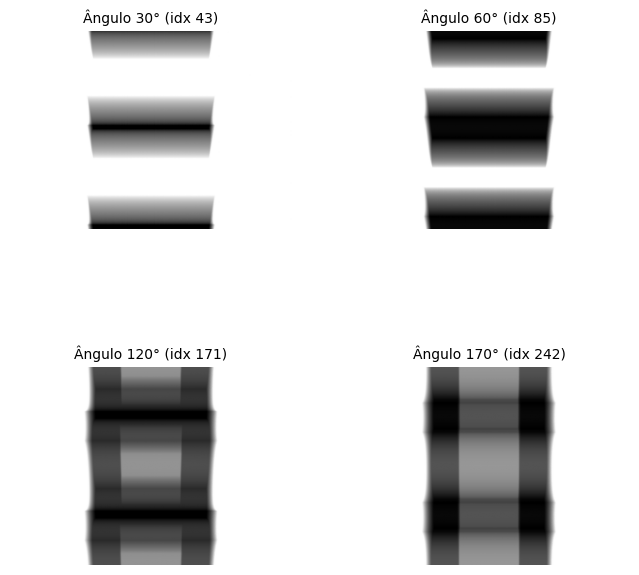

In [15]:
angles_projections_to_plot = [30, 60, 120, 170]
plot_four_projections_by_angle(projections, angles=angles_projections_to_plot)

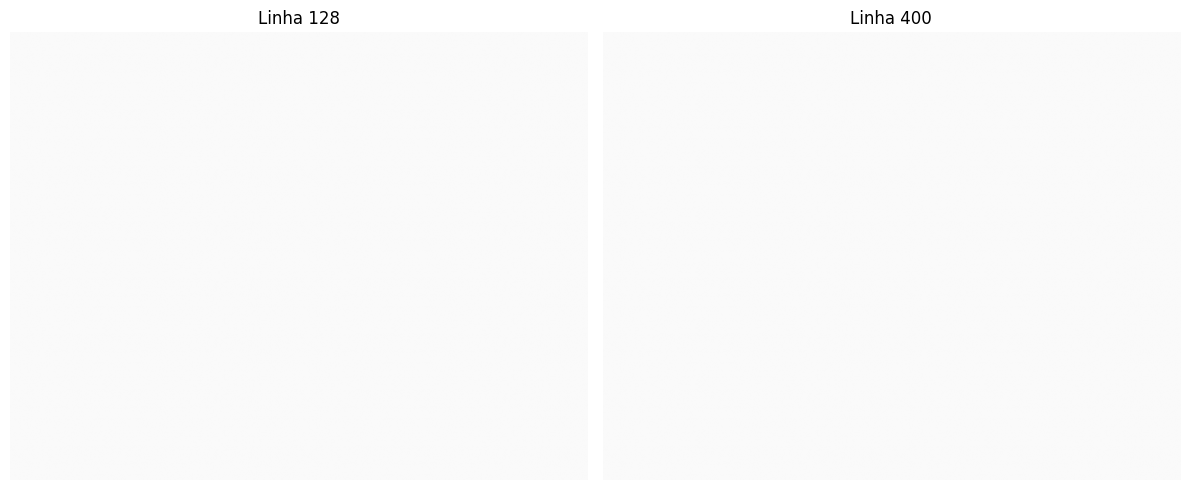

In [16]:
plot_two_sino_planes(projections, lines = [128, 400], vmin=0, vmax=projections.max()*1.0)

## Visualizar histograma das projeções

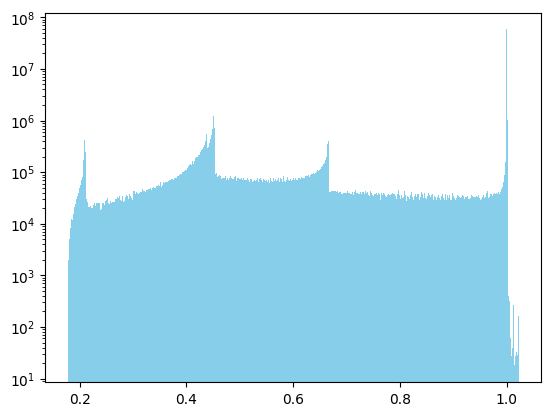

In [17]:
#Construir o histograma
fig = plt.figure()
ax = plt.axes()
ax.hist(projections[:,:,:].flatten(), bins=512, color='skyblue', log=True)
plt.show()

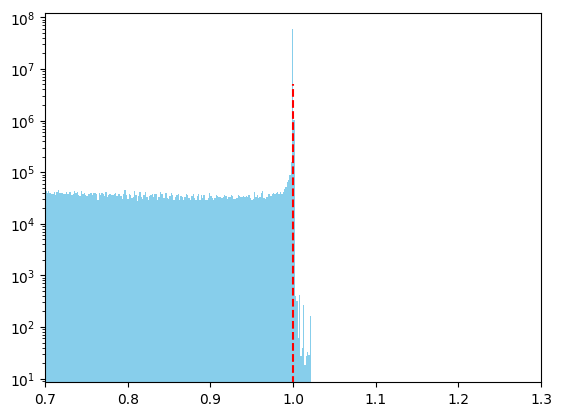

In [18]:
#Pico do fundo do histograma
fig = plt.figure()
ax = plt.axes()
ax.hist(projections[:,:,:].flatten(), bins=512, color='skyblue', log=True)
ax.plot([1.0, 1.0], [0, 5e6], 'r--')
ax.set_xlim(0.7, 1.3)
plt.show()

## Tratar projeções para o formato do TIGRE

In [19]:
projections_ln = -np.log(projections / 1.0)

count = (projections_ln < 0).sum()
total = projections_ln.size
print(f'Projeções com valores negativos: {count} de {total} ({count/total:.2%})')

Projeções com valores negativos: 13585827 de 94371840 (14.40%)


In [20]:
#Elimina os valores negativos
projections_ln[np.isnan(projections_ln)] = 0
projections_ln[np.isinf(projections_ln)] = 0
projections_ln[projections_ln < 0] = 0

print('Projeções negativas eliminadas.')
print(f'Valores mínimos e máximos após tratamento: {projections_ln.min()}, {projections_ln.max()}')

Projeções negativas eliminadas.
Valores mínimos e máximos após tratamento: 0.0, 1.728652000427246


## Configurar geometria no TIGRE

In [21]:
#%% Definir a geometria
geo = tigre.geometry_default(high_resolution=True)

# Distances
geo.DSD = 500  # Distance Source Detector      (mm)
geo.DSO = 400  # Distance Source Origin        (mm)

# Detector parameters
geo.nDetector = np.array([512, 512])  # número de pixels do detector
geo.dDetector = np.array([0.2, 0.2])  # tamanho de cada pixel (mm)
geo.sDetector = geo.nDetector * geo.dDetector  # tamanho total do detector (mm)

# Image parameters
geo.nVoxel = np.array([512, 512, 512])  # número de voxels (ajuste conforme necessário)
geo.sVoxel = np.array([81.92, 81.92, 81.92])  # tamanho total da imagem (mm) igual ao FOV
geo.dVoxel = geo.sVoxel / geo.nVoxel  # tamanho de cada voxel (mm)

geo.accuracy = 0.25  # precisão do cálculo da projeção (mm)

In [22]:
# Angles for projections
angles = np.linspace(0, 359, 360, endpoint=True)

# Convert to radians
angles = np.deg2rad(angles)

print("Geometria: ", geo)
print("Acurácia da geometria: ", geo.accuracy)
print("Formato dos angulos: ", angles.shape)
print("Ângulos (radianos): ", angles)

listGpuNames = gpu.getGpuNames()
if len(listGpuNames) == 0:
    print("Error: No gpu found")
else:
    for id in range(len(listGpuNames)):
        print("{}: {}".format(id, listGpuNames[id]))

gpuids = gpu.getGpuIds(listGpuNames[0])
print("GPU ID: ", gpuids)

imgFDK = algs.ossart(projections_ln, geo, angles, niter=5, gpuids=gpuids)

print('FDK:', imgFDK.shape, imgFDK.min(), imgFDK.max(), imgFDK.mean())

Geometria:  TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 500 mm
Distance from source to origin (DSO)= 400 mm
-----
Detector parameters
Number of pixels (nDetector) = [512 512]
Size of each pixel (dDetector) = [0.2 0.2] mm
Total size of the detector (sDetector) = [102.4 102.4] mm
-----
Image parameters
Number of voxels (nVoxel) = [512 512 512]
Total size of the image (sVoxel) = [81.92 81.92 81.92] mm
Size of each voxel (dVoxel) = [0.16 0.16 0.16] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [0 0] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.25
Acurácia da geometria:  0.25
Formato dos angulos:  (360,)
Ângulos (radianos):  [0.         0.01745329 0.03490659 0.05235988 0.06981317 0.08726646
 0.10471976 0.12217305 0.13962634 0.15707963 0.17453293 0.19198622
 0.20943951 0.2268928  0.2443461  0.26179939 0.27925268 0.29670597
 0.31415927

## Visualizar geometria

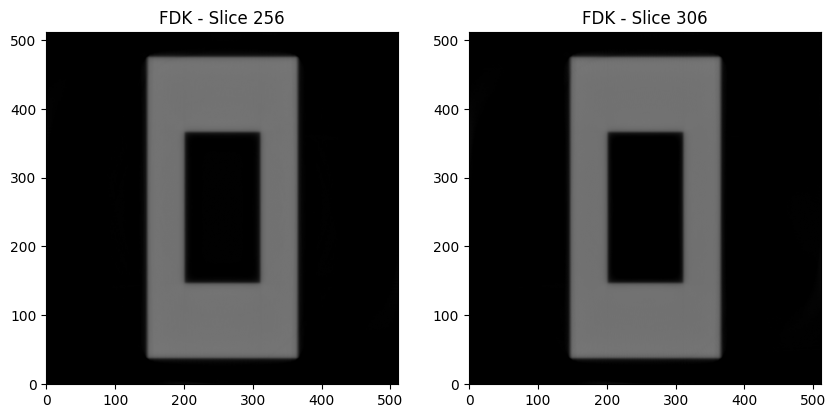

In [23]:
fig, ax = plt.subplot_mosaic([[0, 1]], figsize=(10, 6))

_slice = 256  # valor dentro do range

ax[0].imshow(imgFDK[_slice, :, :], cmap="gray", vmin=0, vmax=0.05)
ax[0].set_title(f'FDK - Slice {_slice}', fontsize = 12)
ax[0].invert_yaxis()
ax[1].imshow(imgFDK[_slice+50, :, :], cmap="gray", vmin=0, vmax=0.05)
ax[1].set_title(f'FDK - Slice {_slice+50}', fontsize = 12)
ax[1].invert_yaxis()

In [24]:
print(imgFDK.min(), imgFDK.max())

0.0 0.025985295


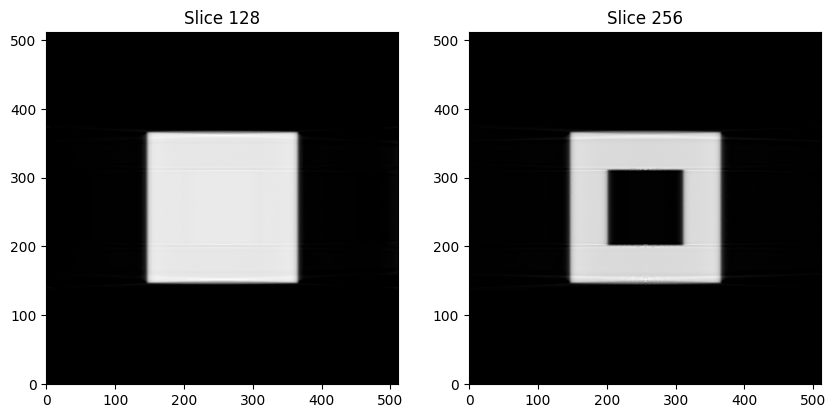

In [25]:
fig, ax = plt.subplot_mosaic([[0, 1]], figsize=(10, 6))

_slice = 256  # ou outro valor dentro do range do seu volume

ax[0].imshow(imgFDK[:, _slice//2, :], cmap="gray")
ax[0].set_title(f'Slice {_slice//2}', fontsize=12)
ax[0].invert_yaxis()
ax[1].imshow(imgFDK[:, _slice, :], cmap="gray")
ax[1].set_title(f'Slice {_slice}', fontsize=12)
ax[1].invert_yaxis()

## Salvar o volume reconstruído

In [26]:
np.savez('../output/volume.npz', volume=imgFDK)